In [4]:
# Instalar la librería NumPy si no está disponible
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Instalar matplotlib para visualizar gráficos e imágenes
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
# Importar librerías necesarias
# - NumPy: para operaciones numéricas
# - pyplot: para visualización de gráficos
import numpy as np
from numpy import random
from matplotlib import pyplot as plt

# Habilitar gráficos inline en Jupyter
%matplotlib inline

In [ ]:
# Función para visualizar imágenes en una cuadrícula
# Parámetros:
# - samples: lista de imágenes a mostrar
# - m: número de filas en la cuadrícula
# - n: número de columnas en la cuadrícula
def view_samples(samples, m, n):
    fig, axes = plt.subplots(figsize=(10,10), nrows=m, ncols=n, sharey=True, sharex=True)
    for ax, img in zip(axes.flatten(), samples):
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        # Mostrar imagen invertida (1-img) en escala de grises
        im = ax.imshow(1-img.reshape((4,4)), cmap='Greys_r')
    return fig, axes

In [ ]:
# Generar ruido aleatorio y función para crear imágenes aleatorias
noise = [np.random.randn(4,4) for i in range(20)]

# Función para generar una imagen aleatoria normalizada entre 0 y 1
def generate_random_image():
    return [np.random.random() for _ in range(16)]

In [9]:
# Función sigmoide: f(x) = e^x / (1 + e^x)
# Usada como función de activación en las redes
def sigmoid(x):
    return np.exp(x)/(1.0+np.exp(x))

In [ ]:
noise = [np.random.randn(4,4) for i in range(20)]
def generate_random_image():
    return [np.random.random() for _ in range(16)]

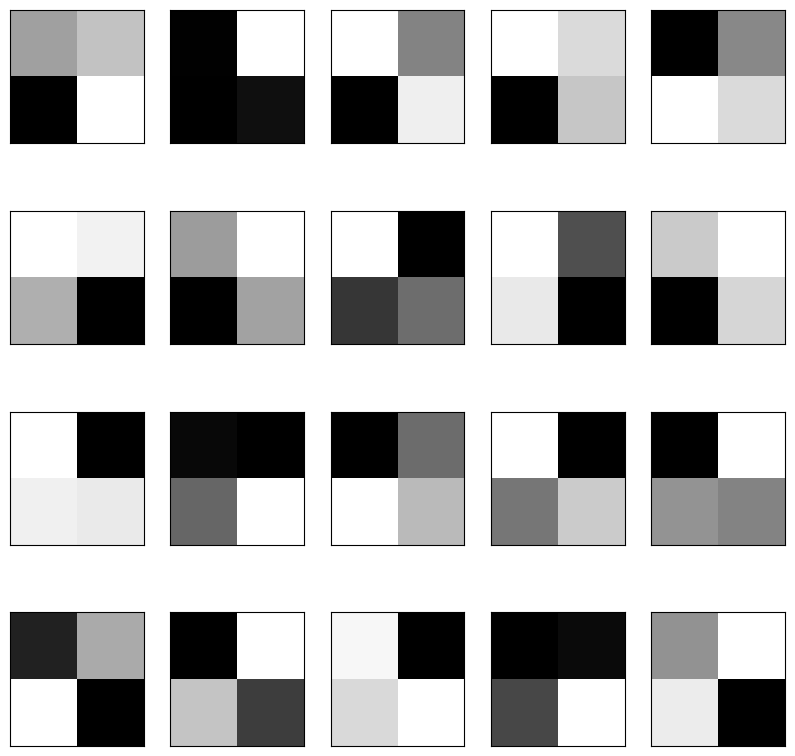

In [11]:
noise_view = view_samples(noise, 4, 5)

In [12]:
def sigmoid(x):
    return np.exp(x)/(1.0+np.exp(x))

In [13]:
sigmoid(1)

np.float64(0.7310585786300049)

In [ ]:
# DISCRIMINADOR: Identifica si una imagen es real (de las caras) o falsa (generada)
# Parámetros:
# - weights: pesos para la combinación lineal de entrada
# - bias: sesgo
class Discriminator():
    def __init__(self):
        # Inicializar pesos y sesgo con valores aleatorios normales (16 píxeles para 4×4)
        self.weights = np.array([np.random.normal() for i in range(16)])
        self.bias = np.random.normal()

    # Pasada hacia adelante: combinación lineal + sigmoide
    def forward(self, x):
        return sigmoid(np.dot(x, self.weights) + self.bias)

    # Calcular error para imagen real (debe predecir 1)
    def error_from_image(self, image):
        prediction = self.forward(image)
        return -np.log(prediction)

    # Calcular gradientes con respecto a una imagen real
    def derivatives_from_image(self, image):
        prediction = self.forward(image)
        derivatives_weights = -image*(1-prediction)
        derivative_bias = -(1-prediction)
        return derivatives_weights, derivative_bias

    # Actualizar pesos y sesgo usando gradiente descendente (imágenes reales)
    def update_from_image(self, x):
        ders = self.derivatives_from_image(x)
        self.weights -= learning_rate * ders[0]
        self.bias -= learning_rate * ders[1]

    # Calcular error para imagen falsa (debe predecir 0)
    def error_from_noise(self, noise):
        prediction = self.forward(noise)
        return -np.log(1-prediction)

    # Calcular gradientes con respecto a una imagen falsa
    def derivatives_from_noise(self, noise):
        prediction = self.forward(noise)
        derivatives_weights = noise*prediction
        derivative_bias = prediction
        return derivatives_weights, derivative_bias

    # Actualizar pesos y sesgo usando gradiente descendente (imágenes falsas)
    def update_from_noise(self, noise):
        ders = self.derivatives_from_noise(noise)
        self.weights -= learning_rate * ders[0]
        self.bias -= learning_rate * ders[1]

In [ ]:
# GENERADOR: Crea imágenes falsas que intenta que parezcan reales
# Parámetros:
# - weights: multiplicadores para la entrada de ruido
# - biases: valores de sesgo para cada salida
class Generator():
    def __init__(self):
        # Inicializar pesos y sesgos con valores aleatorios normales (16 píxeles para 4×4)
        self.weights = np.array([np.random.normal() for i in range(16)])
        self.biases = np.array([np.random.normal() for i in range(16)])

    # Pasada hacia adelante: aplicar pesos y sesgos al ruido
    def forward(self, z):
        return sigmoid(z*self.weights+self.biases)

    # Calcular error: qué tan bien logra engañar al discriminador
    def error(self, z, discriminator):
        x = self.forward(z)
        y = discriminator.forward(x)
        return -np.log(y)

    # Calcular gradientes respecto a los parámetros del generador
    def derivatives(self, z, discriminator):
        discriminator_weights = discriminator.weights
        discriminator_bias = discriminator.bias
        x = self.forward(z)
        y = discriminator.forward(x)
        factor = -(1-y)*discriminator_weights * x * (1-x)
        derivatives_weights = factor*z
        derivative_bias = factor
        return derivatives_weights, derivative_bias
    
    # Actualizar pesos y sesgos usando gradiente descendente
    def update(self, z, discriminator):
        error_before = self.error(z, discriminator)
        ders = self.derivatives(z, discriminator)
        self.weights -= learning_rate * ders[0]
        self.biases -= learning_rate * ders[1]
        error_after = self.error(z, discriminator)

    # Generar imagen final a partir del ruido
    def generate_image(self, z):
        generated_image = self.forward(z)
        return generated_image.reshape((4,4))

In [ ]:
# ENTRENAMIENTO MANUAL: Entrenamiento iterativo del Generador y Discriminador
# Fijar semilla aleatoria para reproducibilidad
np.random.seed(42)

# Definir caras de entrenamiento (4×4 píxeles = 16 valores)
faces = [
    np.array([1, 0, 0, 1,
              0, 1, 1, 0,
              1, 0, 0, 1,
              0, 1, 1, 0], dtype=float),  # Cara patrón 1
    np.array([0.9, 0.1, 0.2, 0.8,
              0.1, 0.9, 0.9, 0.1,
              0.8, 0.1, 0.1, 0.8,
              0.2, 0.8, 0.8, 0.2], dtype=float),  # Cara patrón 2
    np.array([0.8, 0.2, 0.1, 0.9,
              0.2, 0.8, 0.8, 0.2,
              0.9, 0.1, 0.2, 0.8,
              0.1, 0.9, 0.9, 0.1], dtype=float),  # Cara patrón 3
    np.array([0.7, 0.3, 0.3, 0.7,
              0.3, 0.7, 0.7, 0.3,
              0.7, 0.3, 0.3, 0.7,
              0.3, 0.7, 0.7, 0.3], dtype=float),  # Cara patrón 4
]

# Hiperparámetros del entrenamiento
learning_rate = 0.05  # Tasa de aprendizaje para ambas redes
epochs = 50000  # Número de iteraciones de entrenamiento

# Inicializar Generador y Discriminador
D = Discriminator()
G = Generator()

# Listas para registrar errores durante el entrenamiento
errors_discriminator = []
errors_generator = []

# Bucle principal de entrenamiento
for epoch in range(epochs):
    # Para cada imagen real de caras
    for face in faces:
        # 1. Entrenar discriminador con imagen real
        D.update_from_image(face)
        # 2. Generar ruido aleatorio
        z = random.rand()
        # 3. Generar imagen falsa
        fake_image = G.forward(z)
        # 4. Registrar errores del discriminador
        errors_discriminator.append(float(D.error_from_image(face) + D.error_from_noise(fake_image)))
        # 5. Registrar error del generador
        errors_generator.append(float(G.error(z, D)))
        # 6. Entrenar discriminador con imagen falsa
        D.update_from_noise(fake_image)
        # 7. Entrenar generador
        G.update(z, D)

NameError: name 'faces' is not defined

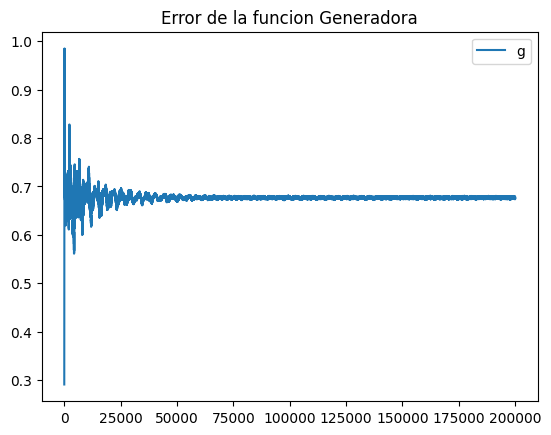

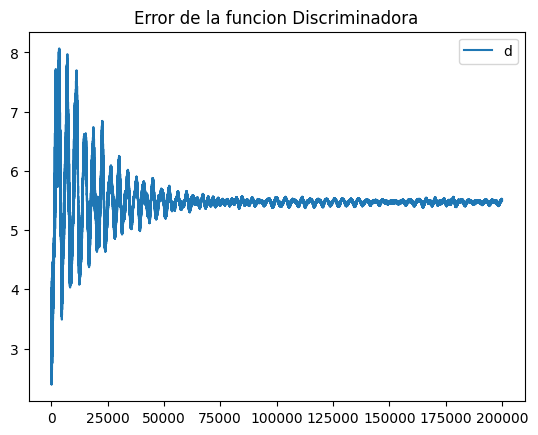

In [ ]:
# Graficar el error del generador durante el entrenamiento
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(errors_generator)
plt.title("Error de la función Generadora (4×4)")
plt.xlabel("Iteración")
plt.ylabel("Error")
plt.grid(True, alpha=0.3)

# Graficar el error del discriminador durante el entrenamiento
plt.subplot(1, 2, 2)
plt.plot(errors_discriminator)
plt.title("Error de la función Discriminadora (4×4)")
plt.xlabel("Iteración")
plt.ylabel("Error")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

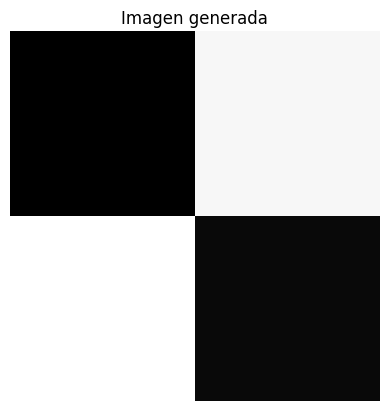

In [ ]:
# Generar y mostrar una imagen final del generador entrenado
z_final = random.rand()  # Generar ruido final
generated_image = G.generate_image(z_final)
plt.figure(figsize=(6, 6))
plt.imshow(1-generated_image, cmap='Greys_r', interpolation='nearest')
plt.title("Imagen generada 4×4 después del entrenamiento")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Fin del notebook
# Este código implementa una GAN básica para generar imágenes pequeñas (4×4 píxeles)
# El generador aprende a crear imágenes que se parecen a caras simples
# El discriminador aprende a distinguir imágenes reales de generadas